### Python Exercise #3
### Chosen API: BlueSky
### By: Melissa Tuniewicz

**Concept Overview:** In my Data Schema assignment, I created a museum centered around microtrends, with the viral Starbucks Holiday 2025 Bearista cup as the main focus of my analysis. This cup was part of a massive social media hype cycle, and demand for the product was extremely high. Customers camped out overnight outside Starbucks locations on the morning prior to the November 6th launch, hoping to be among the few able to purchase one. However, when the doors finally opened, stock was extremely limited (Bakhtiari, 2025). Naturally, this sparked online outrage and brought issues of overconsumption and scarcity marketing to the forefront. Because of this, the Bearista cup serves as a compelling case study, so I decided to revisit the concept and explore it further in this assignment.

**Comparative Element**: Using Melissa's Bluesky API key, we will be loading 500 posts and sorting the pre-launch and post launch content into their own dataframes. So one dataframe for posts prior to Novmeber 6th and another dataframe for any comments made after. I will be conducting a sentiment analysis that will give insight on the emotional tone of user statements.

**Research Question:** There are two themes we aim to explore through this sentiment analysis. The first involves examining how hype cycles form on social media, which primarily focuses on influencer marketing and the FOMO that emerges when users encounter viral content. This will be done through a close reading of the posts our dataframe The second theme explores the emotional manipulation embedded in platform-driven behavior, particularly scarcity marketing (an essential component of platform capitalism). For this component, we'll be looking to our data visualization for further insights.

**Our Initial Predictions:** Prior to the product launch, users will express excitement after seeing the cup appear on their social media feeds, and many will express interest in purchasing this trendy item for themselves. After the launch, however, we expect the responses to become overwhelmingly negative, with complaints about Starbucks locations intentionally limiting stock despite high demand, as well as frustration over the extremely high resale prices appearing in second-hand markets.

---

In [2]:
# Atproto is a python library that lets you interact with bluesky, let's make sure to install the package properly
!pip install atproto

from atproto import Client

# Here are Melissa's login credentials that we'll be using to access the Bluesky API (no peeking!)
client = Client()
profile = client.login('melissatuniewicz.bsky.social', 'Henrypeter4!')

# Let's make sure my display name properly prints
print("Logged in as:", profile.display_name)

Logged in as: melissa tuniewicz


In [12]:
# Login Worked, Yay! Now, let's move onto logging in and starting to generate posts.
# This code converts Melissa's Bluesky username into a DID
from atproto import client_utils


resp = client.com.atproto.identity.resolve_handle(
    {"handle": "aoc.bsky.social"}
)
did = resp.did
print(did)

did:plc:p7gxyfr5vii5ntpwo7f6dhe2


In [13]:
# This code will generate 500 Bluesky posts

# The datetime module supplies classes for manipulating dates and times.
# Since I'll need to examine specific timelines, it will be useful to have this information present in my data.
# Source: https://docs.python.org/3/library/datetime.html

from datetime import datetime
from dateutil import parser   # This library converts strings into datetime objects

# Max_posts sets the amount of posts I want to collect at 500
MAX_POSTS = 500

# To ensure that I have enough content to analyze, lets make sure to scrape multiple keywords by creating a list!
KEYWORDS = [
    "bearista cup",
    "starbucks bearista",
    "starbucks cup",
    "starbucks bear",
    "starbucks bear cup"
]

all_posts = []

# Loop through each keyword separately (because OR does not work in Bluesky search)
# An error we encountered: Instead of looping keywords seperately, we used "OR" between keywords, but the keywords did not process, so the amount of posts generated did not increase!
for QUERY in KEYWORDS: # initializes or resets the pagination cursor before each keyword's data retrieval.
    cursor = None

    while len(all_posts) < MAX_POSTS:
        response = client.app.bsky.feed.search_posts(
            {"q": QUERY, "limit": 100, "cursor": cursor} # Limit of 100
        )

        posts = response.posts
        if not posts:
            break  # No more results for this keyword

        all_posts.extend(posts)
        cursor = response.cursor

        if cursor is None:
            break  # No more pages for this keyword



# Remove duplicate posts based on URI
unique_posts = {post.uri: post for post in all_posts}
all_posts = list(unique_posts.values())

# Trim to exactly 500 if we got more
all_posts = all_posts[:MAX_POSTS]


# Print results
for post in all_posts:
    handle = post.author.handle
    timestamp = post.record.created_at

    dt = parser.isoparse(timestamp)
    time = dt.strftime("%Y-%m-%d %I:%M %p")

    likes = post.like_count or 0
    reposts = post.repost_count or 0
    text = post.record.text.replace('\n', ' ')  # Optional: clean up line breaks
    # And if we do this right, it'll print out the 500 posts we need to start organizing them into the rest of our research!

    print(f"{handle} | {time} | reposts:{reposts} | likes:{likes} | {text}")


virtualnews360.bsky.social | 2026-02-11 06:04 PM | reposts:0 | likes:0 | Madison Chock, Evan Bates’ Olympics 2026 Scoring Controversy  Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More Madison Chock and Evan Bates’ path to an Olympics 2026 gold medal was supposed to be a smooth skate. At least, that’s the reputation the Team USA skating…
virtualnews360.bsky.social | 2026-02-09 02:09 PM | reposts:0 | likes:0 | Kevin Federline, Britney Spears Skiing Trick  Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More Oh baby, baby how were we supposed to know that Britney Spears and Kevin Federline would be included in Olympics 2026? Turns out, the “...Baby One More Time” singer and…
fllicsofficial.bsky.social | 2026-02-08 08:04 PM | reposts:0 | likes:0 | Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks’ Bearista Cup and More  Hahna Norman revealed that her Team USA goodie bag featured the viral Starbucks Bearista cup.
v

### Quick Note Regarding Keywords (Fixing an Error) (Jasmeen)

At first, our Bluesky query was simply “bearista,” and when we looked through the posts we generated, many of them were not about the cup at all, but instead about general experiences at coffee shops. Several users had made spelling errors and wrote “bearista” instead of “barista” when they were trying to refer to any regular barista at a coffee shop. To fix this issue, we refined our query by to "starbucks bearista cup” to ensure that the posts were actually about the product in question.

This really speaks to the importance of having effective keywords!

It also helps us stress the importance of how such a new concept/launch can take over the market of consumerism. Close reading and analysis really helped us figure out if the first 500 posts found were actually pertaining to our topic, or if they were just spelling errors!

---


### Time to load our dataframe!

In [14]:
# Now that we have grabbed our posts, lets load all of this into a dataframe
# I consulted section #3 of the Week-10-BlueskyAPi notebook for how to execute this code
# As the lecture slides show in week 10, the code looks something like this:

import pandas as pd

bluesky_list = []

for post in all_posts:
    author = post.author.handle  # collect handle first (we anonymize later)

    timestamp = post.record.created_at
    dt = parser.isoparse(timestamp)
    time = dt.strftime("%Y-%m-%d %I:%M %p")
    likes = post.like_count or 0
    reposts = post.repost_count or 0
    text = post.record.text.replace('\n', ' ')  # Optional cleanup

    bluesky_list.append([author, time, likes, reposts, text])

# Create the DataFrame
Bluesky_Dataframe = pd.DataFrame(
    bluesky_list,
    columns=["Author", "Time", "Likes", "Reposts", "Text"]
)

# Creating the DataFrame will help us sort all of the posts, keywords and the overall analysis now that it's defined!
# Create author ID column (using the factorize technique from class)
Bluesky_Dataframe["Author_ID"] = pd.factorize(Bluesky_Dataframe["Author"])[0]


# Drop the Author column entirely this allows for full anonymization)
Bluesky_Dataframe = Bluesky_Dataframe.drop(columns=["Author"])

# Create dataframe with all required categories
Bluesky_Dataframe = Bluesky_Dataframe[["Author_ID", "Time", "Likes", "Reposts", "Text"]]

# Display without truncation
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

Bluesky_Dataframe.head() ### increase the value in .head() to render more columns of the dataframe

# With all of the columns names and labelled, the code should generate all of our texts into organized charts and columns,
# making it easier to distinguish where certain info goes where and why!


,Author_ID,Time,Likes,Reposts,Text
0,0,2026-02-11 06:04 PM,0,0,"Madison Chock, Evan Bates’ Olympics 2026 Scoring Controversy Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More Madison Chock and Evan Bates’ path to an Olympics 2026 gold medal was supposed to be a smooth skate. At least, that’s the reputation the Team USA skating…"
1,0,2026-02-09 02:09 PM,0,0,"Kevin Federline, Britney Spears Skiing Trick Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More Oh baby, baby how were we supposed to know that Britney Spears and Kevin Federline would be included in Olympics 2026? Turns out, the “...Baby One More Time” singer and…"
2,1,2026-02-08 08:04 PM,0,0,Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks’ Bearista Cup and More Hahna Norman revealed that her Team USA goodie bag featured the viral Starbucks Bearista cup.
3,0,2026-02-08 04:41 PM,0,0,"Team USA’s Olympics 2026 Gift Bag Features Starbucks’ Bearista Cup There's a certain badassery built into a sport that entails hurtling headfirst on a tiny sled down a twisty track at speeds of up to 90 miles per hour. But Ro, the first American to medal in skeleton in 12 years at the IBSF World…"
4,2,2026-02-08 04:30 PM,2,0,Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More bit.ly/4qmKc9y


---
### Quick Note: Ethical Data Handling (Melissa)

As we learned in the Week-10-Youtube-API notebook, it is good practice to avoid collecting identifying data unless absolutely necessary. Obviously, having user handles would do little to enhance our analysis, so we're going to use the pandas **factorize** method to assign ID numbers to users rather than to disclose their names.

### Before We Conduct a Sentiment Analysis, Let's Clean Up the Data (Jasmeen)

Let’s use Regex to filter posts from November only! After closely examining the posts in our dataframe, we noticed that several entries were from early months before November and even from late 2024. Since the Bearista cup was first announced at the beginning of November 2025, any posts outside this time frame were likely unrelated to the topic. Including them in our sentiment analysis would therefore add noise rather than useful insight.


In [6]:
import re
import pandas as pd
from dateutil import parser


# Reload the dataframe from our scraped posts
# This way, all of the posts orginally scrapped won't show up again, which could mess up the data we're working with.

bluesky_list = []

for post in all_posts:
    author = post.author.handle
    timestamp = post.record.created_at
    dt = parser.isoparse(timestamp)

    # Keep readable timestamp string
    #This will help the information come out smoothly and not just blast information at you!
    time_str = dt.strftime("%Y-%m-%d %I:%M %p")

    likes = post.like_count or 0
    reposts = post.repost_count or 0
    text = post.record.text.replace('\n', ' ')

    bluesky_list.append([author, time_str, likes, reposts, text]) # This will change adjust the column names

Bluesky_Dataframe = pd.DataFrame(
    bluesky_list,
    columns=["Author", "Time", "Likes", "Reposts", "Text"]
)


# Anonymize authors
# This way, we're still respecting their privacy, while still being able to use content properly. Even though everything used is public data,
# It's important we use proper and respectful ettiquete, especially when the data doesn't belong to us!

Bluesky_Dataframe["Author_ID"] = pd.factorize(Bluesky_Dataframe["Author"])[0]
Bluesky_Dataframe = Bluesky_Dataframe.drop(columns=["Author"])
Bluesky_Dataframe = Bluesky_Dataframe[["Author_ID", "Time", "Likes", "Reposts", "Text"]]


# Create REGEX pattern to display posts from November 2025 exclusively
# ReGex will help us to move inforamtion into their respective catagories, so we're not getting confused with so much data, and it'll help us find/identify patterns!

# Pattern: any date starting with 2025-11-XX
nov_pattern = r'^2025\-11\-'
# Source: https://forum.keyboardmaestro.com/t/regular-expression-regex-to-filter-by-date/12433

Bluesky_Dataframe = Bluesky_Dataframe[
    Bluesky_Dataframe['Time'].astype(str).str.contains(nov_pattern, regex=True)
]

# Now that we've applied our regex pattern, let's sort the posts into chronological order using ascending=true
# Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html
# This will be useful for close reading!

Bluesky_Dataframe = Bluesky_Dataframe.sort_values(by='Time', ascending=True).reset_index(drop=True)


# Preview the filtered dataframe and save it as a csv
# Now, we can make sure if it's actually showing up the way we intend it to!
Bluesky_Dataframe.to_csv('Bluesky_Chronological.csv', index=False)

Bluesky_Dataframe.head(10)




,Author_ID,Time,Likes,Reposts,Text
0,159,2025-11-04 09:20 PM,1,0,"I haven’t bought a sbx cup in years at this point, but I need that bearista cold cup. Look at it!"
1,158,2025-11-06 01:02 PM,1,0,Dude behind the counter already took 5 calls and told me they were reselling up to $300. Place was only open for 20 minutes.
2,157,2025-11-06 03:20 PM,0,0,"The coffee chain is now offering its holiday drinks and seasonal cups to customers, including a ""bearista"" cup."
3,21,2025-11-06 05:20 PM,0,0,Starbucks adds $30 'Bearista' cup to holiday merchandise. Here's how to get it
4,156,2025-11-06 05:45 PM,1,0,Not people paying $500 for the bearista Starbucks cup or asking almost $6K on eBay This is disgusting
5,155,2025-11-06 06:23 PM,6,2,You see this little bastard right here? My sworn enemy. My opp. The bane of my existence. We got two of these in today and they sold out in seconds. There was a line outside the building for them 45min before we opened. We are receiving phone calls about them at a rate of one call every two minutes
6,154,2025-11-06 06:44 PM,0,0,Really people! Bearista cup madness. It's a fudgin' cup that looks like a bear with a straw in it. It's probably made in China. www.delish.com/food-news/a6...
7,7,2025-11-06 07:15 PM,0,0,Starbucks' new 'Bearista' cup is causing a stir — and is being listed on eBay for $600 ©
8,7,2025-11-06 07:15 PM,0,0,"Starbucks apologizes after 'Bearista' cup sparks fights, long lines and $500 resale listings ©"
9,52,2025-11-06 08:24 PM,3,0,This was the line at my Starbucks to get the new Bearista cup at 5am .... We only got 6 of them and people waited over night for them.... I'm glad I didn't work this morning... #starbucks #holidaylaunch #bearista #barista


---
### Let's Do a Sentiment Analysis! 

Sentiment analysis is a valuable Natural Language Processing (NLP) tool that helps determine the emotional tone of a piece of text by classifying it as positive, negative, or neutral. For our analysis, we will focus on the compound score, as it provides an overall sentiment measure. We believe that including the individual positive and negative scores will not add value to our analysis.


### Addressing An Error (Jasmeen)

We realized that we had forgotten to save our cleaned-up DataFrame as a CSV after initially processing it. As a result, when we revisited the notebook later, the posts were completely out of order. To prevent this issue from happening again, we implemented a filter to sort the posts by ascending date (when we created the dataframe above) and immediately saved the sorted DataFrame to a CSV file. This way, we can ensure the data remains consistent and chronologically ordered across future sessions.



In [15]:
# Before we install vader sentiment, let's save the above dataframe as a CSV
Bluesky_Dataframe.to_csv('Bluesky_Chronological.csv', index=False)


# This code will install Vader sentiment
!pip install vaderSentiment

#Next we'll import sentiment analysis and some additional tools from the library
import vaderSentiment.vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create an instance of the sentiment analyzer
sentimentAnalyser = SentimentIntensityAnalyzer()

In [16]:
# Apply VADER sentiment analysis to the Text column
def analyze_sentiment(text):
    scores = sentimentAnalyser.polarity_scores(text)
    return scores['compound']  # Return only the compound score (positve, negative and neutral aren't necessary for us)

# Create a new single 'Sentiment' column
Bluesky_Dataframe['Sentiment'] = Bluesky_Dataframe['Text'].apply(analyze_sentiment)

# Show the updated DataFrame (optional)
Bluesky_Dataframe.head()

# Everything looks great! The sentiment column appeared, and everything is in chronological order as required

,Author_ID,Time,Likes,Reposts,Text,Sentiment
0,0,2026-02-11 06:04 PM,0,0,"Madison Chock, Evan Bates’ Olympics 2026 Scoring Controversy Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More Madison Chock and Evan Bates’ path to an Olympics 2026 gold medal was supposed to be a smooth skate. At least, that’s the reputation the Team USA skating…",0.7184
1,0,2026-02-09 02:09 PM,0,0,"Kevin Federline, Britney Spears Skiing Trick Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More Oh baby, baby how were we supposed to know that Britney Spears and Kevin Federline would be included in Olympics 2026? Turns out, the “...Baby One More Time” singer and…",0.4019
2,1,2026-02-08 08:04 PM,0,0,Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks’ Bearista Cup and More Hahna Norman revealed that her Team USA goodie bag featured the viral Starbucks Bearista cup.,0.4404
3,0,2026-02-08 04:41 PM,0,0,"Team USA’s Olympics 2026 Gift Bag Features Starbucks’ Bearista Cup There's a certain badassery built into a sport that entails hurtling headfirst on a tiny sled down a twisty track at speeds of up to 90 miles per hour. But Ro, the first American to medal in skeleton in 12 years at the IBSF World…",0.7140
4,2,2026-02-08 04:30 PM,2,0,Inside Team USA’s Olympics 2026 Gift Bag Featuring Starbucks' Bearista Cup and More bit.ly/4qmKc9y,0.4404


### How we could have improved our code/analysis (Jasmeen)

The cleaned-up dataframe contains only 370 posts from November, falling short of the recommended 500. In the future, we would use a different API, such as Twitter, which has a much larger user base than Bluesky and therefore offers significantly more content to work with. Despite creating a list of multiple keywords, we were unable to reach the target amount, which limits the depth of the analytical portion of this study. However, we will still do our best to make meaningful inferences and conduct close readings to help supplement the gaps in the quantitative data.

---

### Close Reading (Do these posts help us with answering our research question?) (Melissa)

Prior to the creation of the dataframe, we predicted that pre-launch posts were going to be more positive filled with remarks full of anticipation and excitment, likely after the cup began to circulate social media feeds rapidly. While there was only a small amount of posts from before November 6th, our predictions appear to be correct. 

***Pre-Launch***

***Example #1-***
***November 4th (2 days before launch): "I haven’t bought a sbx cup in years at this point, but I need that bearista cold cup. Look at it!"***
* This postis from an excited customer, who expresses great desire in acquring the cup for herself after seeing it online
* Compund sentiment analysis score: 0 (Neutral)
* Although a neutral score, this post was quite enthusiastic
* This post clearly shows how FOMO is created. The cup has yet to launch, and customers are displaying copious excitement

***Example #2-***
***November 6th (morning before launch): "The coffee chain is now offering its holiday drinks and seasonal cups to customers, including a "bearista" cup."***
* This post is likely from an influencer, who's trying to create hype about the launch and convince consumers of its utility
* Sentiment score: 0.4 (Neutral-Positive)
* This post shows clearly how the cup was heavily promoted online, which evidenly created much consumer anticipation

***Post-Launch:***

***Example #1-***
***November 7th (day after launch): "I would cut a bitch for a Starbucks Bearista ornament"***
* This post is likely from an individual who did not manage to secure a cup of their own. Perhaps they waited in line only to be met with dissapointment when the cups sold out quickly
* Sentiment score: -0.7096 (Negative)
* This speaks to the second part of our research question about the impacts of scarcity culture on consumers. This individual feels exluded from participating in a viral social media trend, and begins to act aggressively as a result


### Outliers
***Example #1-*** 
***November 9th: "I’m all for chasing your passions, but I will never understand the Starbucks Bearista cup hype. You won’t catch me outside a Starbucks at 3am for a $30 cup. 🤣🤣:***
* Sentiment score: 0.94 (Extremely positive)
* This post is extremely interesting. The user is evidently criticizing overconsumption and the hype surrounding the cup, but VADER sentiment is interpreting the tone as positive. This is likely due to the user's use of laughing emojis, which VADER tends to associate with positive sentiment due to them being ***amplifiers***. This is a testament to how NLP models struggle to distinguish sarcasm from neutral text.
* Source: Week-10-LyricsGeniusAPI notebook

***Example #2-***
***November 9th: "I can’t believe I’m saying this... but I want the stupid cup."***
* Sentiment score:-0.48 (Moderate-Negative)
* The user is expressing enthusiasm about the cup but uses aggressive language to do so. VADER sentiment interprets words like “stupid” as signals of negative emotional tone, even though the user’s intent is clearly positive.
* This highlights how NLP models like VADER struggle to detect positive sentiment when it's expressed using aggressive or sarcastic language.

***An interesting question we could ask based on the above response:*** How do users express frustration with overconsumption while simultaneously participating in it?




---
### Visualization 

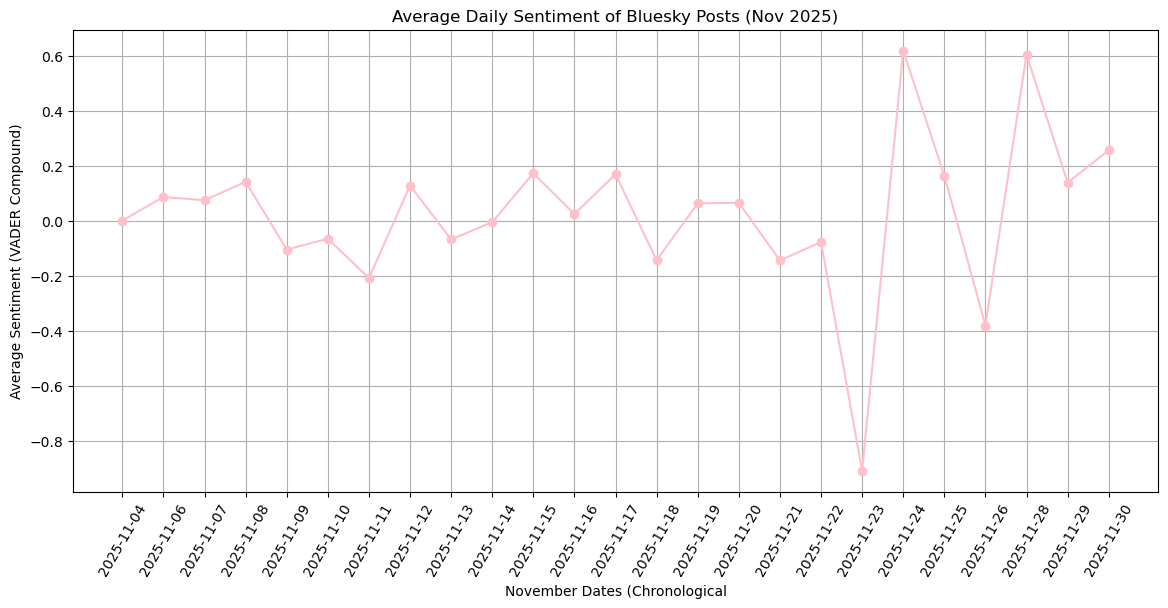

In [11]:
# Convert timestamp to date only
# We don't need extra stuff popping onto the graphs, so limiting it to dates only helps the reader understand better!
Bluesky_Dataframe['DateOnly'] = Bluesky_Dataframe['Time'].str.slice(0, 10) # Slices first ten characters, so the date format is correct

# Compute mean sentiment per day
daily_sentiment = Bluesky_Dataframe.groupby('DateOnly')['Sentiment'].mean()

import matplotlib.pyplot as plt
# We will be creating a line graph for our visualizations, since they are effective in analyzing trends over a time period

plt.figure(figsize=(14, 6)) # Height and width of our chart in inches
plt.plot(daily_sentiment.index, daily_sentiment.values, marker='o', color='pink') # marker=o creates adds circles at the end of each data point

# Of course we're going to use the colour pink

plt.xticks(rotation=60)
plt.xlabel("November Dates (Chronological") # X-axis label
plt.ylabel("Average Sentiment (VADER Compound)")  # Y-axis label
plt.title("Average Daily Sentiment of Bluesky Posts (Nov 2025)") # Plot title
plt.grid(True) # turn on grid lines
plt.show() #display chart



In [10]:
# Yipee! The graph plots work! The data shows up well, along with the dates and the X/Y Values! This way, we're able to easily see the number of times the sentiment of BlueSky Posts appear!


### Insights from visualization

The line graph illustrates how sentiment fluctuates in response to scarcity-driven marketing. Sharp spikes and drops in daily sentiment suggest emotional highs and viral moments prior to the product launch on November 6th, followed by frustration or backlash when the item becomes unavailable. This emotional volatility reflects how platform-driven scarcity manipulates user behavior, reinforcing the cyclical nature of hype and disappointment that fuels engagement in platform capitalism.

### Reflection: 

***Overview of case study***

This exercise was designed as a case study exploring the psychological implications of social media–driven product hype cycles and scarcity marketing, using the 2025 Starbucks holiday merchandise launch as a lens, with the now-infamous Bearista cup at the forefront of the analysis. The objective was to compare sentiment around the cup’s launch before and after November 6th, with the prediction that users would express excitement and anticipation prior to the release, followed by a sharp shift toward negativity after the launch. This shift was expected due to widespread online frustration over Starbucks intentionally releasing limited quantities, leaving the majority of customers empty-handed. This wasn’t a typical holiday launch; anticipation reached a level where customers camped outside of Starbucks locations overnight, hoping to be first in line when stores opened. This extreme behavior sparked my curiosity: how were everyday Bluesky users reacting to the situation? After all, it’s just a glass cup, so I wondered if others shared my view that this was simply another fleeting microtrend fueling the culture of overconsumption, amplified by influencer marketing and targeted advertising on platforms like TikTok and Instagram.

***How I used Bluesky API to answer my questions***

In an attempt to answer these questions, I collected approximately 500 posts from Bluesky using a small list of keywords to ensure I had as much relevant content as possible. Despite my best efforts, I didn’t quite reach the recommended number of 500 posts. Initially, I searched using only the keyword “bearista,” but many of the results had nothing to do with the Bearista microtrend and were simply typos of the word “barista.” Realizing this, I expanded my keyword list to include terms like “cup” and “Starbucks” to improve the relevance of the dataset. Even after modifying the code, I still fell short of the target, which I believe is due to Bluesky being a relatively niche platform with fewer active users and less overall content. If I were to do this assignment again, my analysis would likely be more effective using the Twitter (now X) API, given its significantly larger user base of over 600 million. Unfortunately, we weren’t able to explore the Twitter API in class, so Bluesky was the next best option available.

***Biases***

In order to ensure that our dataframe contained content appropriate for analysis, it was important to consider potential biases within the dataset. Because this study includes topics that may evoke varying levels of sensitivity, such as overconsumption and psychological manipulation through platform capitalism, we made sure not to include any personally identifiable information. It is easy to place the blame for compulsive purchasing on impressionable social media users. However, influencer marketing and targeted advertising play a major role in creating artificial need. These systems are designed to trigger FOMO and comparison culture, making consumers more likely to purchase products in order to “keep up.” To address these concerns, we used the factorize() technique to replace user handles with ID numbers, rendering the data fully anonymous.

***Can the dataframe and visualization help me answer my research questions? & What other questions could be useful to consider?***

The results from my chronologically ordered dataframe and line graph aligned with my expectations. After closely reading several posts, it became clear that more positive and neutral sentiments were expressed about the cup prior to and on launch day, compared to the social media chaos that followed. I cannot help but wonder if users would have reacted differently if the cup had not been released in such limited quantities. If there had been enough supply to meet demand, would sentiments have remained more neutral? As a collector myself, I have noticed that one of the most pressing issues with modern collectibles is scarcity marketing. When those who genuinely desire an item are unable to purchase one due to lack of supply, it can severely damage the brand’s image. These frustrations often extend beyond the collecting community and begin to shape public sentiment as well. While it may appear to be an issue of overconsumption, the deeper problem often lies in the marketing tactics companies use to manufacture urgency and drive demand. 

Unfortunately, there were very few posts from before November 6th, which limited the depth of the visualization analysis. While the sentiment fluctuations still aligned with my initial predictions, the sparsity of the dataset makes it more difficult to demonstrate statistical significance. However, meaningful inferences and conclusions can still be drawn from the available data.

Two days prior to the launch (November 4th), sentiment surrounding the cup was neutral, with a compound score of 0. On the evening before the launch, sentiment rose to nearly 0.3, signifying growing anticipation among users planning to purchase the product. The day after the launch, sentiment dropped slightly and became more neutral, followed by a sharp decline between November 8th and 11th. During this period, sentiment became significantly more negative, and reactions to the scarcity issue grew increasingly hostile. I conducted a close reading of posts from that timeframe and found a noticeable shift in tone. Many users expressed frustration with the hype cycle, as well as with Starbucks itself. On November 10th, User ID 58 wrote:

***"I had to take a little edible to deal with everyone’s shit. I went to TikTok for a break and somehow ended up in the Starbucks Bearista algorithm. A bunch of middle-aged women crashing out over what looks to me like a goddamn sippy cup. 30 bucks and nowhere near enough to meet demand."***

This post simultaneously highlights the impacts of corporate greed and offers a critique of microtrends, arguing that the Bearista cup contributes to the overconsumption crisis while offering little practical value. It is also interesting to note how overconsumption is gendered in this critique, as it is often associated with women, who are stereotypically seen as more vulnerable to social pressure and lifestyle ideals. This is another bias worth acknowledging in this case study, as my aim is not to blame women for being targets of manipulation, but to hold exploitative marketing practices accountable.

***Conclusion***

To conclude, elements of my research question were definitely addressed, although a higher-quality dataset would have made the analysis much stronger. Nonetheless, this was an interesting study that deepened my understanding of the negative implications of microtrends, scarcity marketing, and platform capitalism. Social media platforms often act as conversion funnels, driving traffic toward trendy products and creating a heightened sense of desire for unnecessary items. The use of NLP tools like VADER Sentiment was helpful in quickly analyzing emotional reactions over time and making inferences about whether my predictions were accurate. While my analysis and code would have benefited from an API capable of providing more than 500 posts, I was still able to work effectively with the limited dataset and arrive at meaningful conclusions!!


### Works Cited

Bakhtiari, K. (2025). Starbucks Bearista Cup Frenzy leaves Big Lessons for brands. Forbes. https://www.forbes.com/sites/kianbakhtiari/2025/11/16/the-starbucks-bearista-cup-frenzy-and-the-big-lessons-for-brands/ 

Unknown. (2025). Datetime - basic date and time types. Python documentation. https://docs.python.org/3/library/datetime.html

Unknown. (2025). Pandas.dataframe.sort_values#. pandas.DataFrame.sort_values - pandas 2.3.3 documentation. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html 